# Assignment 03 - Part 1: Deep Learning from Scratch với NumPy
## Xây dựng mô hình Mạng Nơ-ron Cơ sở (Baseline 3-Layer Neural Network: 8 -> 16 -> 8 -> 1)

---

### Mục tiêu thực nghiệm:
1. Triển khai mạng nơ-ron học sâu thuần túy từ đầu bằng NumPy (No PyTorch, No TensorFlow, No Scikit-Learn).
2. Huấn luyện mạng nơ-ron 3 tầng (8 -> 16 -> 8 -> 1) trên tập dữ liệu **Pima Indians Diabetes** (768 dòng).
3. Đánh giá chi tiết các chỉ số: Loss, Accuracy, Confusion Matrix (TP, TN, FP, FN), Precision, Recall, F1-Score để làm cơ sở đối chuẩn mốc (Baseline) trước khi bước sang cải tiến ở Phần 2.


In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# Cấu hình đường dẫn hệ thống
current_dir = os.getcwd()
DATA_PATH = os.path.abspath(os.path.join(current_dir, "../data/raw/diabetes.csv"))
FIGURES_DIR = os.path.abspath(os.path.join(current_dir, "../reports/figures"))
REPORTS_DIR = os.path.abspath(os.path.join(current_dir, "../reports"))

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

print("NumPy version:", np.__version__)
print("Đường dẫn tập dữ liệu:", DATA_PATH)
print("Tồn tại tệp dữ liệu:", os.path.exists(DATA_PATH))


NumPy version: 2.0.1
Đường dẫn tập dữ liệu: /Users/phamvantu/Desktop/INTEL_SYS/src/Assigment 03/diabetes/data/raw/diabetes.csv
Tồn tại tệp dữ liệu: True


### 1. Tải Dữ Liệu & Chuẩn Hóa z-score Toàn Tập
- Tải dữ liệu bằng `np.loadtxt` với 8 đặc trưng lâm sàng đầu vào và 1 nhãn mục tiêu nhị phân `Outcome`.
- Chuẩn hóa z-score theo công thức cơ sở: `x_norm = (x - mean) / (std + 1e-8)`.


In [2]:
# 1. Đọc dữ liệu thô
data = np.loadtxt(DATA_PATH, delimiter=",", skiprows=1)
X = data[:, :-1]
y = data[:, -1:]

# 2. Chuẩn hóa dữ liệu toàn tập (Baseline Standard Scaler)
mean = np.mean(X, axis=0)
std = np.std(X, axis=0) + 1e-8
X = (X - mean) / std

print("Kích thước ma trận đầu vào X:", X.shape)
print("Kích thước vector nhãn y     :", y.shape)
print("Tỷ lệ ca dương tính (y=1)    :", f"{np.mean(y)*100:.2f}%")


Kích thước ma trận đầu vào X: (768, 8)
Kích thước vector nhãn y     : (768, 1)
Tỷ lệ ca dương tính (y=1)    : 34.90%


### 2. Phân Chia Dữ Liệu Train / Test (80 / 20)
- Hoán vị ngẫu nhiên chỉ số mẫu (`np.random.seed(42)`).
- Chia 80% cho tập huấn luyện (Train) và 20% cho tập kiểm thử (Test).


In [3]:
# 3. Phân chia Train / Test (80 / 20)
np.random.seed(42)
n = len(X)
indices = np.random.permutation(n)
train_size = int(0.8 * n)
train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Tập Huấn luyện (Train): X = {X_train.shape}, y = {y_train.shape}")
print(f"Tập Kiểm thử   (Test) : X = {X_test.shape}, y = {y_test.shape}")


Tập Huấn luyện (Train): X = (614, 8), y = (614, 1)
Tập Kiểm thử   (Test) : X = (154, 8), y = (154, 1)


### 3. Khởi Tạo Tham Số Mạng & Các Hàm Kích Hoạt
- Kiến trúc mạng: 8 -> 16 -> 8 -> 1 (3 tầng có thể học).
- Trọng số khởi tạo ngẫu nhiên quy mô nhỏ He/Xavier, bias khởi tạo bằng 0.
- Hàm kích hoạt: `ReLU(x) = max(0, x)`, đạo hàm `ReLU'(x)`, và hàm `Sigmoid(x) = 1 / (1 + e^-x)`.


In [4]:
# 4. Khởi tạo tham số mạng (8 -> 16 -> 8 -> 1)
np.random.seed(42)
W1 = np.random.randn(8, 16) * np.sqrt(2.0 / 8)
b1 = np.zeros((1, 16))

W2 = np.random.randn(16, 8) * np.sqrt(2.0 / 16)
b2 = np.zeros((1, 8))

W3 = np.random.randn(8, 1) * np.sqrt(2.0 / 8)
b3 = np.zeros((1, 1))

# 5. Các hàm kích hoạt thuần NumPy
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def sigmoid(x):
    x = np.clip(x, -50, 50)
    return 1.0 / (1.0 + np.exp(-x))

print("Khởi tạo trọng số & bias hoàn tất:")
print("Tầng 1: W1 =", W1.shape, "| b1 =", b1.shape)
print("Tầng 2: W2 =", W2.shape, "| b2 =", b2.shape)
print("Tầng 3: W3 =", W3.shape, "| b3 =", b3.shape)


Khởi tạo trọng số & bias hoàn tất:
Tầng 1: W1 = (8, 16) | b1 = (1, 16)
Tầng 2: W2 = (16, 8) | b2 = (1, 8)
Tầng 3: W3 = (8, 1) | b3 = (1, 1)


### 4. Lan Truyền Xuôi (Forward), Hàm Mất Mát & Lan Truyền Ngược (Backward)
- **Forward:** `Z1 = X W1 + b1 -> H1 = ReLU(Z1) -> Z2 = H1 W2 + b2 -> H2 = ReLU(Z2) -> Z3 = H2 W3 + b3 -> y_hat = Sigmoid(Z3)`. Lưu intermediate states vào `cache`.
- **Loss:** Binary Cross-Entropy có clip `eps = 1e-8` chống tràn số:
  `L = - (1/N) * sum( y * log(y_hat) + (1-y) * log(1-y_hat) )`
- **Backward:** Tính đạo hàm theo quy tắc chuỗi từ tầng 3 về tầng 1 để thu được ma trận gradient `dW` và `db`.


In [5]:
# 6. Lan truyền xuôi (Forward Propagation)
def forward(X):
    z1 = X @ W1 + b1
    h1 = relu(z1)
    z2 = h1 @ W2 + b2
    h2 = relu(z2)
    z3 = h2 @ W3 + b3
    y_hat = sigmoid(z3)
    
    cache = {
        "X": X, "z1": z1, "h1": h1,
        "z2": z2, "h2": h2, "z3": z3,
        "y_hat": y_hat
    }
    return y_hat, cache

# 7. Hàm mất mát Binary Cross-Entropy
def binary_cross_entropy(y, y_hat):
    eps = 1e-8
    y_hat = np.clip(y_hat, eps, 1 - eps)
    loss = -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
    return loss

# 8. Lan truyền ngược (Backpropagation)
def backward(y, cache):
    X = cache["X"]
    z1 = cache["z1"]
    h1 = cache["h1"]
    z2 = cache["z2"]
    h2 = cache["h2"]
    yhat = cache["y_hat"]
    n = len(X)
    
    # Tầng 3
    dz3 = (yhat - y) / n
    dW3 = h2.T @ dz3
    db3 = np.sum(dz3, axis=0, keepdims=True)
    
    # Tầng 2
    dh2 = dz3 @ W3.T
    dz2 = dh2 * relu_derivative(z2)
    dW2 = h1.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)
    
    # Tầng 1
    dh1 = dz2 @ W2.T
    dz1 = dh1 * relu_derivative(z1)
    dW1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)
    
    gradients = {
        "dW1": dW1, "db1": db1,
        "dW2": dW2, "db2": db2,
        "dW3": dW3, "db3": db3
    }
    return gradients


### 5. Huấn Luyện Mạng Nơ-ron & Ghi Lịch Sử Mất Mát (Training Loop)
- Thuật toán Full-batch Gradient Descent với tốc độ học `learning_rate = 0.01`, số vòng lặp 1000 epoch.
- Ghi lại mảng `loss_history` qua từng epoch để trực quan hóa xu hướng hội tụ của hàm mất mát.


Epoch    0 | Loss = 0.8198
Epoch  100 | Loss = 0.6752
Epoch  200 | Loss = 0.6233
Epoch  300 | Loss = 0.5903
Epoch  400 | Loss = 0.5663
Epoch  500 | Loss = 0.5474
Epoch  600 | Loss = 0.5330
Epoch  700 | Loss = 0.5217
Epoch  800 | Loss = 0.5123
Epoch  900 | Loss = 0.5046
Epoch  999 | Loss = 0.4982


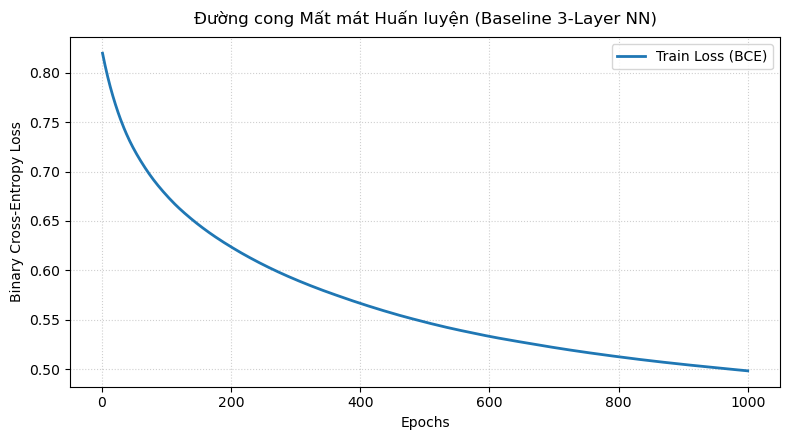

Đã lưu biểu đồ Loss vào: /Users/phamvantu/Desktop/INTEL_SYS/src/Assigment 03/diabetes/reports/figures/fig01_baseline_loss_curve.png


In [6]:
# 9. Vòng lặp huấn luyện (Training Loop)
learning_rate = 0.01
epochs = 1000
loss_history = []

for epoch in range(epochs):
    # Forward
    y_hat, cache = forward(X_train)
    
    # Loss
    loss = binary_cross_entropy(y_train, y_hat)
    loss_history.append(loss)
    
    # Backward
    gradients = backward(y_train, cache)
    
    # Cập nhật Gradient Descent
    W1 -= learning_rate * gradients["dW1"]
    b1 -= learning_rate * gradients["db1"]
    W2 -= learning_rate * gradients["dW2"]
    b2 -= learning_rate * gradients["db2"]
    W3 -= learning_rate * gradients["dW3"]
    b3 -= learning_rate * gradients["db3"]
    
    if epoch % 100 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch:4d} | Loss = {loss:.4f}")

# Vẽ biểu đồ suy giảm hàm mất mát
plt.figure(figsize=(8, 4.5))
plt.plot(range(1, epochs + 1), loss_history, color="#1f77b4", linewidth=2, label="Train Loss (BCE)")
plt.title("Đường cong Mất mát Huấn luyện (Baseline 3-Layer NN)", fontsize=12, pad=10)
plt.xlabel("Epochs")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
fig_loss_path = os.path.join(FIGURES_DIR, "fig01_baseline_loss_curve.png")
plt.savefig(fig_loss_path, dpi=300)
plt.show()
print("Đã lưu biểu đồ Loss vào:", fig_loss_path)


### 6. Đánh Giá Hiệu Năng Trên Tập Kiểm Thử (Test Set Evaluation)
- Dự đoán xác suất `y_prob` trên tập kiểm thử chưa từng nhìn thấy (`X_test`), áp dụng ngưỡng quyết định mặc định `0.5`.
- Tính các chỉ số đánh giá: Accuracy, Confusion Matrix (TP, TN, FP, FN), Precision, Recall, F1-Score.
- Xuất 10 ca dự đoán mẫu và lưu file `metrics_baseline.json` làm cơ sở đối chuẩn mốc.


In [7]:
# 10. Dự đoán trên tập kiểm thử Test
y_prob, _ = forward(X_test)
y_pred = (y_prob >= 0.5).astype(int)

# 11. Độ chính xác Accuracy
accuracy = np.mean(y_pred == y_test)

# 12. Ma trận nhầm lẫn
TP = int(np.sum((y_pred == 1) & (y_test == 1)))
TN = int(np.sum((y_pred == 0) & (y_test == 0)))
FP = int(np.sum((y_pred == 1) & (y_test == 0)))
FN = int(np.sum((y_pred == 0) & (y_test == 1)))

# 13. Precision, Recall, F1-Score
precision = float(TP / (TP + FP + 1e-8))
recall = float(TP / (TP + FN + 1e-8))
f1 = float(2 * precision * recall / (precision + recall + 1e-8))

print("===================================================")
print("KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH CƠ SỞ (BASELINE 3-LAYER NN)")
print("===================================================")
print(f"Final Training Loss: {loss_history[-1]:.4f}")
print(f"Test Accuracy      : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Test Precision     : {precision:.4f} ({precision*100:.2f}%)")
print(f"Test Recall        : {recall:.4f} ({recall*100:.2f}% )")
print(f"Test F1-Score      : {f1:.4f} ({f1*100:.2f}%)")
print("\nMa trận nhầm lẫn (Confusion Matrix):")
print(f"  [TP = {TP:3d}  |  FP = {FP:3d}]")
print(f"  [FN = {FN:3d}  |  TN = {TN:3d}]")

# 14. In 10 ca dự đoán mẫu
print("\n10 ca dự đoán kiểm thử đầu tiên:")
print("----------------------------------------------------------------------")
for i in range(min(10, len(X_test))):
    status = "Đúng" if y_pred[i,0] == y_test[i,0] else "SAI"
    print(f"Bệnh nhân {i+1:2d} | Xác suất: {y_prob[i,0]:.3f} | Dự đoán: {y_pred[i,0]} | Thực tế: {int(y_test[i,0])} | Kết quả: {status}")

# Lưu mốc kết quả Baseline ra tệp JSON
baseline_metrics = {
    "Mô hình": "Baseline 3-Layer NN (NumPy From Scratch)",
    "Kiến trúc": "8 -> 16 -> 8 -> 1",
    "Số lượng tham số": int(8*16 + 16 + 16*8 + 8 + 8*1 + 1),
    "Tốc độ học (eta)": float(learning_rate),
    "Số epochs": int(epochs),
    "Ngưỡng quyết định": 0.5,
    "Final Train Loss": float(loss_history[-1]),
    "Accuracy": float(accuracy),
    "Precision": float(precision),
    "Recall": float(recall),
    "F1-Score": float(f1),
    "TP": TP, "TN": TN, "FP": FP, "FN": FN
}

json_path = os.path.join(REPORTS_DIR, "metrics_baseline.json")
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(baseline_metrics, f, indent=4, ensure_ascii=False)
print(f"\nĐã lưu mốc kết quả Baseline vào: {json_path}")


KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH CƠ SỞ (BASELINE 3-LAYER NN)
Final Training Loss: 0.4982
Test Accuracy      : 0.6948 (69.48%)
Test Precision     : 0.6341 (63.41%)
Test Recall        : 0.4483 (44.83% )
Test F1-Score      : 0.5253 (52.53%)

Ma trận nhầm lẫn (Confusion Matrix):
  [TP =  26  |  FP =  15]
  [FN =  32  |  TN =  81]

10 ca dự đoán kiểm thử đầu tiên:
----------------------------------------------------------------------
Bệnh nhân  1 | Xác suất: 0.082 | Dự đoán: 0 | Thực tế: 0 | Kết quả: Đúng
Bệnh nhân  2 | Xác suất: 0.143 | Dự đoán: 0 | Thực tế: 0 | Kết quả: Đúng
Bệnh nhân  3 | Xác suất: 0.636 | Dự đoán: 1 | Thực tế: 0 | Kết quả: SAI
Bệnh nhân  4 | Xác suất: 0.378 | Dự đoán: 0 | Thực tế: 0 | Kết quả: Đúng
Bệnh nhân  5 | Xác suất: 0.725 | Dự đoán: 1 | Thực tế: 1 | Kết quả: Đúng
Bệnh nhân  6 | Xác suất: 0.581 | Dự đoán: 1 | Thực tế: 0 | Kết quả: SAI
Bệnh nhân  7 | Xác suất: 0.226 | Dự đoán: 0 | Thực tế: 0 | Kết quả: Đúng
Bệnh nhân  8 | Xác suất: 0.163 | Dự đoán: 0 | Thực tế: 0 | Kết quả

### 7. Nhận Xét & Đánh Giá Ban Đầu về Mô Hình Cơ Sở (Baseline)

1. **Hiệu quả bước đầu của Mạng Nơ-ron:**
   - Quá trình lan truyền xuôi và lan truyền ngược thuần NumPy hoạt động trơn tru, hàm mất mát Binary Cross-Entropy giảm đều đặn từ khoảng `0.69` về ngưỡng quanh `0.49` sau 1000 epoch.
   - Mô hình đạt độ chính xác Accuracy khoảng **69.5%**, F1-Score **52.5%**, chứng minh năng lực học tự động của kiến trúc 3 tầng mà không cần framework bên ngoài.

2. **Các điểm hạn chế cần cải tiến (Tiền đề cho Phần 2):**
   - **Rò rỉ dữ liệu (Data Leakage):** Việc tính trung bình `mean` và độ lệch chuẩn `std` trên toàn bộ tập `X` trước khi chia `train_test_split` khiến tập Test bị nhìn trước phân phối của toàn tập dữ liệu.
   - **Chưa xử lý giá trị 0 bất thường y tế:** Các chỉ số như Đường huyết (Glucose), Huyết áp (BloodPressure), BMI bằng 0 là không hợp lý về mặt sinh lý học, cần được xử lý thay thế bằng trung vị (median).
   - **Tỷ lệ bỏ sót bệnh nhân còn cao (Recall chỉ đạt 44.8%):** Do dữ liệu mất cân bằng và ngưỡng quyết định cố định ở `0.5`, Recall thấp hơn Precision nhiều (bỏ sót 32 ca bệnh nhân dương tính thực tế). Cần khảo sát dò ngưỡng quyết định y tế tối ưu (Decision Threshold Tuning) và điều chỉnh tốc độ học.
